In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
import numpy as np
import os
import shutil
import zipfile
from sklearn.model_selection import KFold

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/RiceLeafsDisease.zip'

In [ ]:

from sklearn.model_selection import train_test_split


zip_file_path = '/content/drive/MyDrive/RiceLeafsDisease.zip'
extracted_dir = '/content/RiceLeafsDisease'
output_dir = '/content/organized_dataset'


with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_dir)


print("Extracted directory structure:")
for root, dirs, files in os.walk(extracted_dir):
    print("Root:", root)
    print("Directories:", dirs)
    print("Files:", files)
    print("-" * 40)

for split in ['train', 'validation', 'test']:
    for class_name in ['bacterial_leaf_blight', 'healthy', 'leaf_blast', 'leaf_scald']:
        os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

images = []
labels = []

for class_name in ['bacterial_leaf_blight', 'healthy', 'leaf_blast', 'leaf_scald']:
    class_dir = None
    for root, dirs, files in os.walk(extracted_dir):
        if class_name in dirs:
            class_dir = os.path.join(root, class_name)
            break

    if class_dir is None:
        print(f"Warning: Directory for class '{class_name}' not found. Skipping...")
        continue

    for img in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img)
        if os.path.isfile(img_path):
            images.append(img_path)
            labels.append(class_name)

print(f"Total images found: {len(images)}")

if len(images) == 0:
    raise ValueError("No images found in the dataset. Please check the dataset structure.")

train_images, temp_images, train_labels, temp_labels = train_test_split(
    images, labels, test_size=0.3, stratify=labels, random_state=42
)
val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

def move_images(image_list, labels_list, split):
    for img, label in zip(image_list, labels_list):
        dest_dir = os.path.join(output_dir, split, label)
        shutil.copy(img, dest_dir)

move_images(train_images, train_labels, 'train')
move_images(val_images, val_labels, 'validation')
move_images(test_images, test_labels, 'test')

print("Data has been organized successfully.")
print(f"Train set: {len(train_images)} images")
print(f"Validation set: {len(val_images)} images")
print(f"Test set: {len(test_images)} images")


Extracted directory structure:
Root: /content/RiceLeafsDisease
Directories: ['RiceLeafsDisease']
Files: []
----------------------------------------
Root: /content/RiceLeafsDisease/RiceLeafsDisease
Directories: ['leaf_blast', 'healthy', 'bacterial_leaf_blight', 'leaf_scald']
Files: ['desktop.ini']
----------------------------------------
Root: /content/RiceLeafsDisease/RiceLeafsDisease/leaf_blast
Directories: []
Files: ['leaf_blast (187).jpg', 'leaf_blast (184).jpg', 'leaf_blast (331).jpg', 'leaf_blast (270).jpg', 'leaf_blast (21).jpg', 'leaf_blast (217).jpg', 'leaf_blast (308).jpg', 'leaf_blast (169).jpg', 'leaf_blast (251).jpg', 'leaf_blast (279).jpg', 'leaf_blast (266).jpg', 'leaf_blast (137).jpg', 'leaf_blast (226).jpg', 'leaf_blast (77).jpg', 'leaf_blast (17).jpg', 'leaf_blast (48).jpg', 'leaf_blast (295).jpg', 'leaf_blast (11).jpg', 'leaf_blast (107).jpg', 'leaf_blast (274).jpg', 'leaf_blast (330).jpg', 'Leaf_blast  (884).jpg', 'Leaf_blast  (1086).jpg', 'Leaf_blast  (716).jpg', 'l

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np
import os

augmenter = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

dataset_dir = '/content/organized_dataset/train/'
augmented_dir = '/content/augmented_dataset/train/'

os.makedirs(augmented_dir, exist_ok=True)

for class_name in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_name)
    augmented_class_path = os.path.join(augmented_dir, class_name)
    os.makedirs(augmented_class_path, exist_ok=True)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        # Load the image
        img = load_img(img_path, target_size=(150, 150))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        # Generate new images
        i = 0
        for batch in augmenter.flow(img_array, batch_size=1, save_to_dir=augmented_class_path,
                                    save_prefix='aug', save_format='jpg'):
            i += 1
            if i >= 5:
                break

print("✅ Augmented images saved successfully!")


✅ Augmented images saved successfully!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_dir = '/content/augmented_dataset/train'
validation_dir = os.path.join(output_dir, 'validation')

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)


validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical'
)



test_dir = os.path.join(output_dir, 'test')
test_datagen = ImageDataGenerator(rescale=1.0/255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 6270 images belonging to 4 classes.
Found 295 images belonging to 4 classes.
Found 296 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

base_model = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights='imagenet')
for layer in base_model.layers[-20:]:
    layer.trainable = True



model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

optimizer = Adam(learning_rate=0.00005)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])




9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[early_stopping]
)



Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.3158 - loss: 8.6369 - val_accuracy: 0.4068 - val_loss: 7.7716
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.4371 - loss: 7.6927 - val_accuracy: 0.3966 - val_loss: 7.4937
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.4974 - loss: 7.2916 - val_accuracy: 0.4746 - val_loss: 7.0630
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.5626 - loss: 6.9027 - val_accuracy: 0.5085 - val_loss: 6.7667
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.5999 - loss: 6.5028 - val_accuracy: 0.5593 - val_loss: 6.4687
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.6609 - loss: 6.0875 - val_accuracy: 0.5831 - val_loss: 6.2227
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.6672 - loss: 5.7206 - val_accuracy: 0.6102 - val_loss: 5.7456
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.7143 - loss: 5.3226 - val_accu

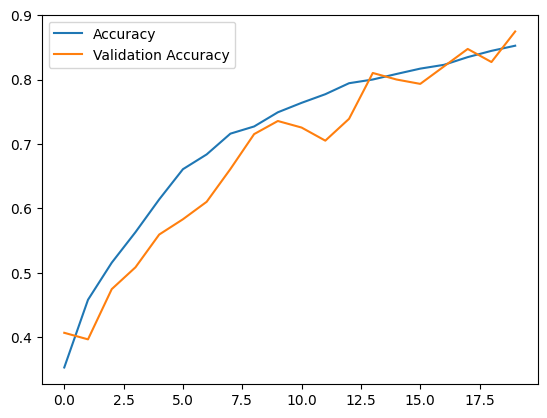

In [ ]:


plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()


In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 504ms/step - accuracy: 0.8978 - loss: 2.0087
Test Accuracy: 90.20%


In [ ]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {train_acc * 100:.2f}%")
print(f"Final Validation Accuracy: {val_acc * 100:.2f}%")

threshold = 0.10

if train_acc - val_acc > threshold:
    print("⚠️ The model is OVERFITTING! Consider applying regularization techniques.")
else:
    print("✅ The model is NOT overfitting.")


Final Training Accuracy: 85.25%
Final Validation Accuracy: 87.46%
✅ The model is NOT overfitting.


10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 772ms/step


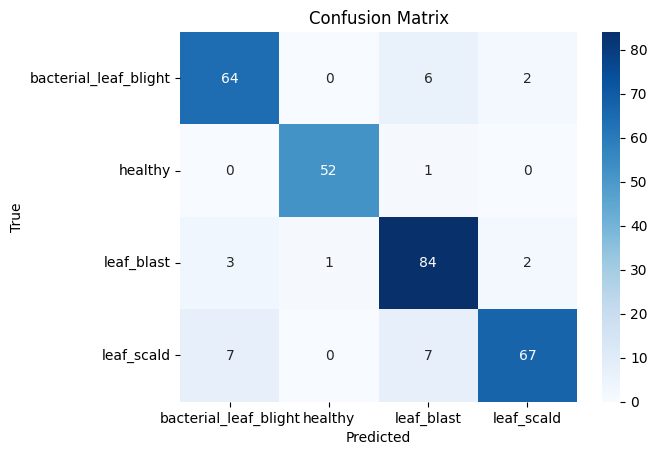

                       precision    recall  f1-score   support

bacterial_leaf_blight       0.86      0.89      0.88        72
              healthy       0.98      0.98      0.98        53
           leaf_blast       0.86      0.93      0.89        90
           leaf_scald       0.94      0.83      0.88        81

             accuracy                           0.90       296
            macro avg       0.91      0.91      0.91       296
         weighted avg       0.90      0.90      0.90       296



In [ ]:
!pip install seaborn
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=1)

conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_generator.class_indices.keys()),
            yticklabels=list(test_generator.class_indices.keys()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

In [ ]:
from tensorflow.keras.preprocessing import image

def classify_image(img_path, model, class_labels, threshold=0.75):
    img = image.load_img(img_path, target_size=(96, 96))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    confidence = np.max(predictions)
    predicted_class = class_labels[np.argmax(predictions)]

    if confidence < threshold:
        return "Cannot recognize or not a trained disease."

    return f"Predicted class: {predicted_class} ({confidence * 100:.2f}%)"

import os
img_path = '/content/foundations-little-scholars-kids-school-chairs-12-in-seat-height_main_1.jpg'
if not os.path.exists(img_path):
    print(f"Error: Image file not found at {img_path}")
else:
    result = classify_image(img_path, model, list(train_generator.class_indices.keys()))
    print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Cannot recognize or not a trained disease.


In [ ]:
from tensorflow.keras.preprocessing import image

def visualize_prediction(img_path, model, class_labels, true_label=None, threshold=0.70):
    img = image.load_img(img_path, target_size=(96, 96))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    confidence = np.max(prediction)
    predicted_class = class_labels[np.argmax(prediction)]

    plt.imshow(image.load_img(img_path))
    plt.axis('off')

    if confidence < threshold:
        plt.title("Cannot recognize or not a trained disease.", fontsize=12)
    else:
        plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)\n"
                  f"True: {true_label if true_label else 'Unknown'}", fontsize=12)

    plt.show()




In [ ]:
from google.colab import files

model_path = "/content/rice_disease_model.h5"


if os.path.exists(model_path):
    files.download(model_path)
    print("Model download started...")
else:
    print("Error: Model file not found. Please check the path.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model download started...
